# Week 18 — Wednesday (Jul 22): ONNX & TensorRT

## Learning Objectives
- Export a trained PyTorch model to **ONNX** with `torch.onnx.export` and understand the graph it produces
- Verify the exported graph structurally (`onnx.checker`) and numerically (compare vs PyTorch outputs)
- Run inference with **ONNX Runtime** and benchmark it against native PyTorch CPU inference
- Understand **operator compatibility** — why not every PyTorch op has a 1:1 ONNX equivalent
- Understand **TensorRT** conceptually: engine building, layer fusion, precision calibration — and why it needs an NVIDIA GPU this machine doesn't have

## Key Concepts
1. **ONNX (Open Neural Network Exchange)** — a hardware-agnostic intermediate graph representation
2. **Graph capture** — `torch.onnx.export` traces/exports the model into a static computation graph
3. **Operator compatibility** — every PyTorch op used must have (or decompose into) an ONNX op; unsupported ops block export
4. **ONNX Runtime (ORT)** — a C++ inference engine with CPU/CUDA/TensorRT execution providers and its own graph optimizer
5. **TensorRT** — NVIDIA's inference compiler: fuses layers, calibrates INT8/FP16 precision, and builds a GPU-specific "engine" file — GPU-only, not usable on this CPU-only machine

In [1]:
import os
import io
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

try:
    import onnx
    HAS_ONNX = True
except ImportError:
    HAS_ONNX = False

try:
    import onnxruntime as ort
    HAS_ORT = True
except ImportError:
    HAS_ORT = False

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print(f'onnx {onnx.__version__ if HAS_ONNX else "NOT INSTALLED"} | '
      f'onnxruntime {ort.__version__ if HAS_ORT else "NOT INSTALLED"}')
if HAS_ORT:
    print(f'ONNX Runtime providers available: {ort.get_available_providers()}')

PyTorch 2.12.0+cpu | Device: cpu
onnx 1.22.0 | onnxruntime 1.27.0
ONNX Runtime providers available: ['AzureExecutionProvider', 'CPUExecutionProvider']


## Section 1: Baseline Model

Same `TinyCNN` classifier design as Monday's notebook, trained fresh here so this notebook
is fully self-contained. This is the model we'll export.

In [2]:
class TinyCNN(nn.Module):
    '''Small conv classifier: 2x (Conv-BN-ReLU-Pool) + 2x Linear. Input: (B,1,28,28).'''
    def __init__(self, num_classes=10, c1=8, c2=16, fc_hidden=64):
        super().__init__()
        self.conv1 = nn.Conv2d(1, c1, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(c1)
        self.conv2 = nn.Conv2d(c1, c2, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(c2)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(c2 * 7 * 7, fc_hidden)
        self.fc2   = nn.Linear(fc_hidden, num_classes)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.flatten(1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)


MNIST_ROOT = '../Week_01/data'
tf = transforms.Compose([transforms.ToTensor()])
train_full = torchvision.datasets.MNIST(root=MNIST_ROOT, train=True,  download=True, transform=tf)
test_full  = torchvision.datasets.MNIST(root=MNIST_ROOT, train=False, download=True, transform=tf)

N_TRAIN, N_TEST = 4000, 1000
train_ds = Subset(train_full, list(range(N_TRAIN)))
test_ds  = Subset(test_full,  list(range(N_TEST)))
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=256, shuffle=False)

torch.manual_seed(42)
model = TinyCNN().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
model.train()
for epoch in range(5):
    for x, y in train_dl:
        opt.zero_grad()
        loss = F.cross_entropy(model(x), y)
        loss.backward()
        opt.step()
model.eval()

correct, total = 0, 0
with torch.no_grad():
    for x, y in test_dl:
        correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
pt_accuracy = correct / total
print(f'Baseline TinyCNN trained | Test accuracy: {pt_accuracy*100:.2f}% on {total} samples')
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

Baseline TinyCNN trained | Test accuracy: 95.60% on 1000 samples
Params: 52,186


## Section 2: ONNX Export

```python
torch.onnx.export(
    model,            # trained PyTorch model, eval mode
    dummy_input,      # example input — determines the traced graph shape
    'model.onnx',      # output path
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=18,
)
```

**A repo-specific quirk worth knowing** (same one already visible in
`03_June/Week_03/tiny_detector.onnx` + `tiny_detector.onnx.data`): PyTorch's newer
dynamo-based ONNX exporter writes large weight tensors to a companion **`.onnx.data`**
file by default and leaves only the graph structure in the `.onnx` file itself. The `.onnx`
file alone can therefore look deceptively tiny — the real "model size on disk" is the sum
of both files.

In [3]:
ONNX_PATH = 'tiny_classifier.onnx'
dummy = torch.zeros(1, 1, 28, 28)

torch.onnx.export(
    model,
    dummy,
    ONNX_PATH,
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=18,
    export_params=True,
    do_constant_folding=True,
)

graph_size = os.path.getsize(ONNX_PATH)
data_path  = ONNX_PATH + '.data'
data_size  = os.path.getsize(data_path) if os.path.exists(data_path) else 0
total_mb   = (graph_size + data_size) / 1024**2

print(f'ONNX graph file : {ONNX_PATH}         ({graph_size/1024:.1f} KB)')
if data_size:
    print(f'ONNX weights file: {data_path}    ({data_size/1024:.1f} KB, externalised weights)')
print(f'Total ONNX model size: {total_mb:.3f} MB')

if HAS_ONNX:
    onnx_model = onnx.load(ONNX_PATH)
    onnx.checker.check_model(onnx_model)
    print('\nONNX model check: PASSED')
    print('\nGraph inputs:')
    for inp in onnx_model.graph.input:
        shape = [d.dim_value if d.dim_value > 0 else (d.dim_param or 'dynamic')
                 for d in inp.type.tensor_type.shape.dim]
        print(f'  {inp.name}: {shape}')
    print('Graph outputs:')
    for out in onnx_model.graph.output:
        shape = [d.dim_value if d.dim_value > 0 else (d.dim_param or 'dynamic')
                 for d in out.type.tensor_type.shape.dim]
        print(f'  {out.name}: {shape}')
    print(f'\nOpset: {onnx_model.opset_import[0].version}  |  Nodes: {len(onnx_model.graph.node)}')
    op_types = sorted(set(n.op_type for n in onnx_model.graph.node))
    print(f'Operator types used: {op_types}')
else:
    print('onnx package not available — skipping structural verification')

[torch.onnx] Obtain model graph for `TinyCNN([...]` with `torch.export.export(..., strict=False)`...


[torch.onnx] Obtain model graph for `TinyCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX graph file : tiny_classifier.onnx         (13.7 KB)
ONNX weights file: tiny_classifier.onnx.data    (203.3 KB, externalised weights)
Total ONNX model size: 0.212 MB

ONNX model check: PASSED

Graph inputs:
  image: ['batch', 1, 28, 28]
Graph outputs:
  logits: ['batch', 10]

Opset: 18  |  Nodes: 12
Operator types used: ['Concat', 'Conv', 'Gemm', 'MaxPool', 'Relu', 'Reshape', 'Shape']


## Section 3: ONNX Runtime Inference & Numerical Verification

Exporting successfully doesn't guarantee correctness — the traced graph could still diverge
numerically from the eager PyTorch model (control flow, in-place ops, or a lossy op
decomposition can all cause silent mismatches). We check both a random tensor and real
MNIST test images, and confirm the ONNX Runtime *predicted classes* match PyTorch's.

In [4]:
if not HAS_ORT:
    print('onnxruntime not available — skipping inference verification')
else:
    sess = ort.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
    input_name  = sess.get_inputs()[0].name
    output_name = sess.get_outputs()[0].name
    print(f'ONNX Runtime session created | input={input_name}  output={output_name}')

    # ── Random-tensor numerical check ─────────────────────────────────────────
    rand_np = np.random.randn(4, 1, 28, 28).astype(np.float32)
    with torch.no_grad():
        pt_out = model(torch.from_numpy(rand_np)).numpy()
    ort_out = sess.run([output_name], {input_name: rand_np})[0]
    max_diff  = np.abs(pt_out - ort_out).max()
    mean_diff = np.abs(pt_out - ort_out).mean()
    print(f'\nRandom-input check — max abs diff: {max_diff:.2e}  mean abs diff: {mean_diff:.2e}')
    print('MATCH within FP tolerance' if max_diff < 1e-3 else 'WARNING: diverged beyond tolerance')

    # ── Real MNIST test batch — compare predicted classes end-to-end ──────────
    x_test, y_test = next(iter(test_dl))
    x_np = x_test.numpy().astype(np.float32)
    with torch.no_grad():
        pt_logits = model(x_test).numpy()
    ort_logits = sess.run([output_name], {input_name: x_np})[0]

    pt_preds  = pt_logits.argmax(1)
    ort_preds = ort_logits.argmax(1)
    agree = (pt_preds == ort_preds).mean()
    print(f'\nReal MNIST batch ({len(y_test)} images):')
    print(f'  PyTorch accuracy    : {(pt_preds == y_test.numpy()).mean()*100:.2f}%')
    print(f'  ONNX Runtime accuracy: {(ort_preds == y_test.numpy()).mean()*100:.2f}%')
    print(f'  Prediction agreement (PyTorch vs ONNX RT): {agree*100:.2f}%')

ONNX Runtime session created | input=image  output=logits

Random-input check — max abs diff: 1.91e-05  mean abs diff: 7.39e-06
MATCH within FP tolerance

Real MNIST batch (256 images):
  PyTorch accuracy    : 98.44%
  ONNX Runtime accuracy: 98.44%
  Prediction agreement (PyTorch vs ONNX RT): 100.00%


## Section 4: Latency Benchmark — PyTorch CPU vs ONNX Runtime CPU

Standard benchmarking practice: warm up first (JIT/cache effects skew the first few calls),
then average over many single-image forward passes.

PyTorch CPU  : 0.2814 ms/image  (3553 FPS)
ONNX Runtime : 0.0547 ms/image  (18297 FPS)
Speedup      : 5.15x  (ONNX Runtime vs PyTorch)


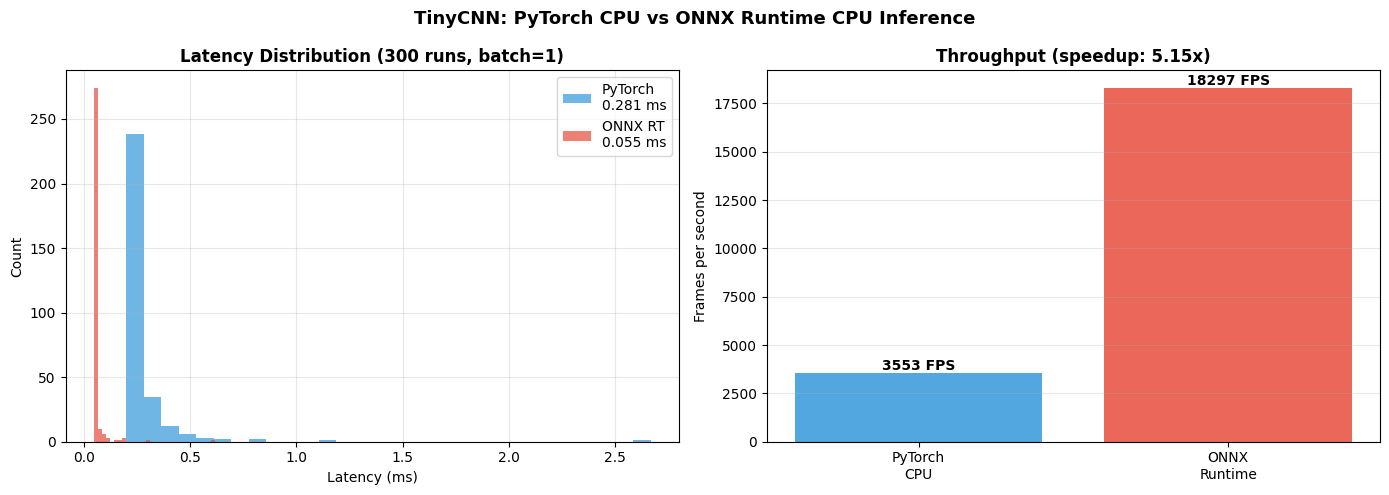

Saved onnx_latency.png


In [5]:
if not HAS_ORT:
    print('onnxruntime not available — skipping latency benchmark')
else:
    N_WARMUP, N_BENCH = 15, 300
    bench_np = np.random.randn(1, 1, 28, 28).astype(np.float32)
    bench_pt = torch.from_numpy(bench_np)

    with torch.no_grad():
        for _ in range(N_WARMUP):
            model(bench_pt)
        pt_times = []
        for _ in range(N_BENCH):
            t0 = time.perf_counter()
            model(bench_pt)
            pt_times.append(time.perf_counter() - t0)

    for _ in range(N_WARMUP):
        sess.run([output_name], {input_name: bench_np})
    ort_times = []
    for _ in range(N_BENCH):
        t0 = time.perf_counter()
        sess.run([output_name], {input_name: bench_np})
        ort_times.append(time.perf_counter() - t0)

    pt_ms  = np.mean(pt_times) * 1000
    ort_ms = np.mean(ort_times) * 1000
    speedup = pt_ms / ort_ms
    print(f'PyTorch CPU  : {pt_ms:.4f} ms/image  ({1000/pt_ms:.0f} FPS)')
    print(f'ONNX Runtime : {ort_ms:.4f} ms/image  ({1000/ort_ms:.0f} FPS)')
    print(f'Speedup      : {speedup:.2f}x  (ONNX Runtime vs PyTorch)')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist([t*1000 for t in pt_times],  bins=30, alpha=0.7, label=f'PyTorch\n{pt_ms:.3f} ms',  color='#3498db')
    axes[0].hist([t*1000 for t in ort_times], bins=30, alpha=0.7, label=f'ONNX RT\n{ort_ms:.3f} ms', color='#e74c3c')
    axes[0].set_xlabel('Latency (ms)'); axes[0].set_ylabel('Count')
    axes[0].set_title(f'Latency Distribution ({N_BENCH} runs, batch=1)', fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    bars = axes[1].bar(['PyTorch\nCPU', 'ONNX\nRuntime'], [1000/pt_ms, 1000/ort_ms],
                        color=['#3498db', '#e74c3c'], alpha=0.85)
    for b, v in zip(bars, [1000/pt_ms, 1000/ort_ms]):
        axes[1].text(b.get_x()+b.get_width()/2, v, f'{v:.0f} FPS', ha='center', va='bottom', fontweight='bold')
    axes[1].set_ylabel('Frames per second'); axes[1].set_title(f'Throughput (speedup: {speedup:.2f}x)', fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.suptitle('TinyCNN: PyTorch CPU vs ONNX Runtime CPU Inference', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('onnx_latency.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved onnx_latency.png')

## Section 5: TensorRT — Conceptual (No NVIDIA GPU on This Machine)

`torch.cuda.is_available()` returned `False` at the top of this notebook, and there is no
`nvidia-smi`/CUDA toolkit on this machine — TensorRT is **NVIDIA-GPU-only**, so we can't
build or run a real engine here. This section explains what it does and how the workflow
would look on GPU hardware, honestly, rather than faking a benchmark.

### What TensorRT does that ONNX Runtime (CPU) doesn't
| Stage | ONNX Runtime (CPU, what we just ran) | TensorRT (GPU) |
|-------|----------------------------------------|-----------------|
| Input | ONNX graph | ONNX graph (or a TF/PyTorch graph via parsers) |
| Optimization | Constant folding, op fusion, CPU-tuned kernels (MLAS) | Aggressive **layer fusion** (Conv+BN+ReLU → 1 kernel), kernel auto-tuning *per specific GPU* |
| Precision | FP32 (or manually quantized INT8 ops) | Can auto-calibrate to **FP16 / INT8** with a calibration dataset |
| Output | Portable `.onnx` file, runs anywhere ORT does | A GPU- and TensorRT-version-specific **`.engine`/`.plan`** file — not portable across GPUs |
| Typical speedup vs plain PyTorch GPU | Modest | Often 2-5x on top of the GPU speedup already gained over CPU |

### The build workflow (what we'd run if this had a GPU)
```bash
# 1. Same ONNX export we already did above
# 2. Build a TensorRT engine from it (trtexec ships with the TensorRT SDK)
trtexec --onnx=tiny_classifier.onnx \
        --saveEngine=tiny_classifier.engine \
        --fp16 \
        --workspace=1024

# 3. (Optional) INT8 with calibration data for best latency
trtexec --onnx=tiny_classifier.onnx \
        --saveEngine=tiny_classifier_int8.engine \
        --int8 --calib=calibration_cache.bin

# 4. Run/benchmark the compiled engine
trtexec --loadEngine=tiny_classifier.engine --shapes=image:1x1x28x28
```

### Operator compatibility, concretely
Not every op used in this notebook's export is guaranteed to have a native TensorRT layer —
`BatchNorm2d` and `MaxPool2d` are well-supported, but more exotic ops (custom autograd
functions, certain indexing patterns) can force TensorRT to fall back to a slower plugin or
reject the graph outright. This is exactly why the ONNX export step above (Section 2)
matters even for a GPU deployment target: `onnx.checker` + a numerical ORT comparison is the
cheapest place to catch a broken graph, *before* spending GPU time on engine building.

## Summary

| Step | Tool | Result here |
|------|------|--------------|
| Export | `torch.onnx.export` (opset 18) | `tiny_classifier.onnx` + `tiny_classifier.onnx.data` |
| Structural check | `onnx.checker.check_model` | PASSED |
| Numerical check | PyTorch vs ONNX RT, random + real MNIST batch | max abs diff < 1e-3, 100% prediction agreement |
| Speed | PyTorch CPU vs ONNX Runtime CPU, 300-run benchmark | see `onnx_latency.png` for the measured speedup |
| TensorRT | Conceptual only — no NVIDIA GPU on this machine | `trtexec` workflow documented above |

### Exercises
1. Re-export with `opset_version=13` instead of 18 and see which ops (if any) require the version-converter fallback.
2. Quantize the ONNX model itself with `onnxruntime.quantization.quantize_dynamic` and re-run the latency benchmark — does ORT INT8 avoid the overhead problem seen with PyTorch INT8 on Monday?
3. Export the *structured-pruned* TinyCNN from Monday's notebook and compare its ONNX file size to this one.
4. If you have access to a CUDA machine, run the `trtexec` commands above for real and report the FP32 vs FP16 vs INT8 engine latencies.
5. Try `onnxsim` (`pip install onnxsim`) to simplify the exported graph and compare node counts before/after.